In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score
    )
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score
    )
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-3
NUM_CLASSES = 5
NUM_WORKERS = 0
SEED = 42

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

In [ ]:
class FlowerNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
def predict_classes(model, x):
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device))
        return logits.argmax(dim=1)

In [ ]:
def evaluate(model, dl, labels):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")

    all_preds, all_targets = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            total_count += y.size(0)
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "loss":     total_loss / total_count,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "report":   classification_report(y_true, y_pred,
                                          target_names=labels,
                                          digits=4, zero_division=0),
    }


# Sanity check: evaluate runs end-to-end on a freshly-instantiated model.
# Pretrained backbone + random head -> predictions should be ~chance (~20%).
_sanity = FlowerNet().to(device)
_metrics = evaluate(_sanity, val_dl, labels)
print(f"[sanity] untrained val: acc={_metrics['accuracy']:.4f} "
      f"macro_f1={_metrics['macro_f1']:.4f} loss={_metrics['loss']:.4f}")
del _sanity

NameError: name 'val_dl' is not defined

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score
    )
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-3
NUM_CLASSES = 5
NUM_WORKERS = 0
SEED = 42

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

In [ ]:
# resize -> center crop -> ImageNet normalization
weights = models.ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()

train_ds = datasets.ImageFolder("flower-splits/train", transform=preprocess)
val_ds   = datasets.ImageFolder("flower-splits/val",   transform=preprocess)
test_ds  = datasets.ImageFolder("flower-splits/test",  transform=preprocess)

labels = train_ds.classes

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
class FlowerNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
def predict_classes(model, x):
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device))
        return logits.argmax(dim=1)

In [ ]:
def evaluate(model, dl, labels):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")

    all_preds, all_targets = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            total_count += y.size(0)
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "loss":     total_loss / total_count,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "report":   classification_report(y_true, y_pred,
                                          target_names=labels,
                                          digits=4, zero_division=0),
    }


# Sanity check: evaluate runs end-to-end on a freshly-instantiated model.
# Pretrained backbone + random head -> predictions should be ~chance (~20%).
_sanity = FlowerNet().to(device)
_metrics = evaluate(_sanity, val_dl, labels)
print(f"[sanity] untrained val: acc={_metrics['accuracy']:.4f} "
      f"macro_f1={_metrics['macro_f1']:.4f} loss={_metrics['loss']:.4f}")
del _sanity

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[sanity] untrained val: acc=0.1782 macro_f1=0.1577 loss=1.6153


In [ ]:
def infinite_iter(dl):
    while True:
        for item in dl:
            yield item

def train(model, optimizer, train_dl, val_dl, num_epochs, name):
    criterion = nn.CrossEntropyLoss()
    out_dir = Path("runs") / name
    out_dir.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   [], "val_macro_f1": []}
    best_val_f1 = -1.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss    += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total   += y.size(0)

        train_loss = running_loss    / running_total
        train_acc  = running_correct / running_total
        val = evaluate(model, val_dl, labels)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["accuracy"])
        history["val_macro_f1"].append(val["macro_f1"])

        print(f"[{name}] epoch {epoch}/{num_epochs}  "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f}  |  "
              f"val: loss={val['loss']:.4f} acc={val['accuracy']:.4f} "
              f"f1={val['macro_f1']:.4f}")

        if val["macro_f1"] > best_val_f1:
            best_val_f1 = val["macro_f1"]
            torch.save(model.state_dict(), out_dir / "best.pt")

    torch.save(model.state_dict(), out_dir / "last.pt")
    with open(out_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    return history

In [ ]:
model = FlowerNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
baseline_history = train(model, optimizer, train_dl, val_dl,
                         num_epochs=NUM_EPOCHS, name="baseline")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[baseline] epoch 1/10  train: loss=0.6295 acc=0.7860  |  val: loss=0.4457 acc=0.8565 f1=0.8555


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[baseline] epoch 2/10  train: loss=0.3299 acc=0.8853  |  val: loss=0.4267 acc=0.8565 f1=0.8582


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[baseline] epoch 8/10  train: loss=0.0870 acc=0.9745  |  val: loss=0.3361 acc=0.8993 f1=0.8978


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[baseline] epoch 9/10  train: loss=0.0850 acc=0.9687  |  val: loss=0.5500 acc=0.8900 f1=0.8900


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[baseline] epoch 10/10  train: loss=0.1655 acc=0.9452  |  val: loss=0.5472 acc=0.8519 f1=0.8533


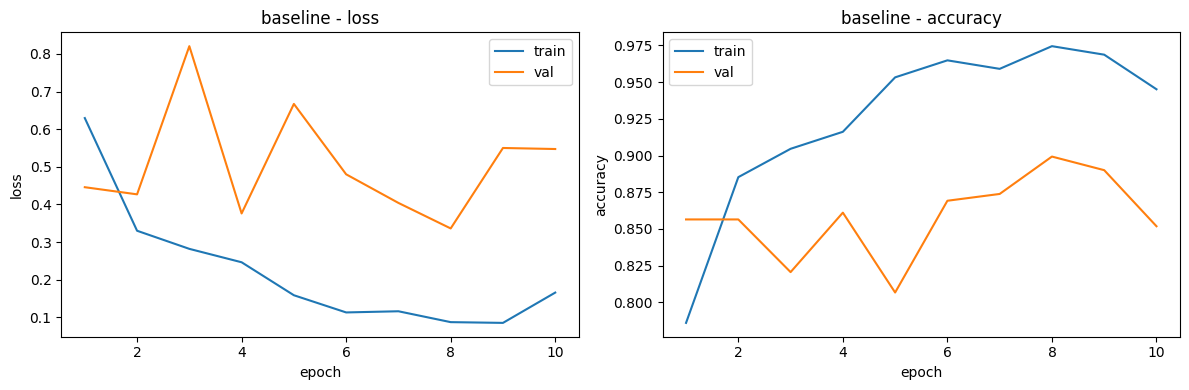

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== baseline / train ===
loss=0.0341  acc=0.9876  macro_f1=0.9874
              precision    recall  f1-score   support

       daisy     0.9702    0.9956    0.9828       458
   dandelion     0.9874    0.9952    0.9913       631
        rose     0.9935    0.9809    0.9872       470
   sunflower     1.0000    0.9773    0.9885       440
       tulip     0.9881    0.9864    0.9873       590

    accuracy                         0.9876      2589
   macro avg     0.9879    0.9871    0.9874      2589
weighted avg     0.9878    0.9876    0.9876      2589

confusion matrix (rows=true, cols=pred):
[[456   2   0   0   0]
 [  1 628   0   0   2]
 [  6   0 461   0   3]
 [  4   4   0 430   2]
 [  3   2   3   0 582]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== baseline / val ===
loss=0.3361  acc=0.8993  macro_f1=0.8978
              precision    recall  f1-score   support

       daisy     0.8735    0.9477    0.9091       153
   dandelion     0.8865    0.9667    0.9248       210
        rose     0.9085    0.8217    0.8629       157
   sunflower     0.9549    0.8639    0.9071       147
       tulip     0.8918    0.8782    0.8849       197

    accuracy                         0.8993       864
   macro avg     0.9030    0.8956    0.8978       864
weighted avg     0.9010    0.8993    0.8987       864

confusion matrix (rows=true, cols=pred):
[[145   5   1   0   2]
 [  3 203   0   2   2]
 [  5   9 129   2  12]
 [  5   7   3 127   5]
 [  8   5   9   2 173]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== baseline / test ===
loss=0.4617  acc=0.8866  macro_f1=0.8840
              precision    recall  f1-score   support

       daisy     0.8571    0.9020    0.8790       153
   dandelion     0.8750    0.9621    0.9165       211
        rose     0.8667    0.8280    0.8469       157
   sunflower     0.9259    0.8562    0.8897       146
       tulip     0.9140    0.8629    0.8877       197

    accuracy                         0.8866       864
   macro avg     0.8877    0.8822    0.8840       864
weighted avg     0.8878    0.8866    0.8861       864

confusion matrix (rows=true, cols=pred):
[[138   9   2   3   1]
 [  3 203   1   3   1]
 [  8   2 130   4  13]
 [  5  15   0 125   1]
 [  7   3  17   0 170]]


In [ ]:
def plot_history(history, name):
    """Save train/val loss + accuracy curves to runs/<name>/curves.png."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(epochs, history["train_loss"], label="train")
    ax_loss.plot(epochs, history["val_loss"],   label="val")
    ax_loss.set(xlabel="epoch", ylabel="loss", title=f"{name} - loss")
    ax_loss.legend()

    ax_acc.plot(epochs, history["train_acc"], label="train")
    ax_acc.plot(epochs, history["val_acc"],   label="val")
    ax_acc.set(xlabel="epoch", ylabel="accuracy", title=f"{name} - accuracy")
    ax_acc.legend()

    fig.tight_layout()
    fig.savefig(Path("runs") / name / "curves.png", dpi=120, bbox_inches="tight")
    plt.show()

def full_eval(model, name):
    """Report loss/accuracy/macro-F1 + classification report on all splits."""
    for split_name, dl in [("train", train_dl), ("val", val_dl), ("test", test_dl)]:
        m = evaluate(model, dl, labels)
        print(f"\n=== {name} / {split_name} ===")
        print(f"loss={m['loss']:.4f}  acc={m['accuracy']:.4f}  "
              f"macro_f1={m['macro_f1']:.4f}")
        print(m["report"])
        print("confusion matrix (rows=true, cols=pred):")
        print(m["cm"])

# Reload the best checkpoint (highest val macro-F1) for reporting.
model.load_state_dict(torch.load("runs/baseline/best.pt", map_location=device))
plot_history(baseline_history, "baseline")
full_eval(model, "baseline")

In [ ]:
# Reuse the matched preprocessing's crop size + normalization so the augmented
# pipeline ends in the exact same value range the pretrained backbone expects.
train_aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess.mean, std=preprocess.std),
])

train_aug_ds = datasets.ImageFolder("flower-splits/train",
                                    transform=train_aug_transform)
train_aug_dl = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)

model_aug = FlowerNet().to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR)
aug_history = train(model_aug, optimizer_aug, train_aug_dl, val_dl,
                    num_epochs=NUM_EPOCHS * 2, name="aug")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[aug] epoch 1/20  train: loss=0.6299 acc=0.7930  |  val: loss=0.6096 acc=0.7963 f1=0.7909


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[aug] epoch 2/20  train: loss=0.4573 acc=0.8393  |  val: loss=0.5776 acc=0.7975 f1=0.7997


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[aug] epoch 18/20  train: loss=0.0943 acc=0.9664  |  val: loss=0.4718 acc=0.8785 f1=0.8800


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[aug] epoch 19/20  train: loss=0.1150 acc=0.9602  |  val: loss=0.3399 acc=0.8924 f1=0.8886


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[aug] epoch 20/20  train: loss=0.1644 acc=0.9486  |  val: loss=0.3395 acc=0.8958 f1=0.8959


In [ ]:
# Swap the backbone family entirely: EfficientNet-B0 (~5M params, mobile-inverted
# bottlenecks) vs ResNet50 (~25M params, residual conv blocks). Same ImageNet
# pretraining, but its weights ship with their own resize/crop and normalization
# stats, so we build matched train/eval transforms for it.
class FlowerNetEffNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

effnet_weights    = models.EfficientNet_B0_Weights.IMAGENET1K_V1
effnet_preprocess = effnet_weights.transforms()

train_effnet_transform = transforms.Compose([
    transforms.RandomResizedCrop(effnet_preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=effnet_preprocess.mean, std=effnet_preprocess.std),
])

train_effnet_ds = datasets.ImageFolder("flower-splits/train",
                                       transform=train_effnet_transform)
val_effnet_ds   = datasets.ImageFolder("flower-splits/val",
                                       transform=effnet_preprocess)
test_effnet_ds  = datasets.ImageFolder("flower-splits/test",
                                       transform=effnet_preprocess)

train_effnet_dl = DataLoader(train_effnet_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=False)
val_effnet_dl   = DataLoader(val_effnet_ds,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False)
test_effnet_dl  = DataLoader(test_effnet_ds,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False)

In [ ]:
model_effnet     = FlowerNetEffNet().to(device)
optimizer_effnet = torch.optim.Adam(model_effnet.parameters(), lr=LR)
effnet_history   = train(model_effnet, optimizer_effnet,
                         train_effnet_dl, val_effnet_dl,
                         num_epochs=NUM_EPOCHS * 2, name="effnet")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/axellangenskiold/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 26.7MB/s]


[effnet] epoch 1/20  train: loss=0.5390 acc=0.8080  |  val: loss=0.3041 acc=0.9097 f1=0.9098
[effnet] epoch 2/20  train: loss=0.3103 acc=0.8899  |  val: loss=0.2361 acc=0.9271 f1=0.9270
[effnet] epoch 3/20  train: loss=0.2212 acc=0.9258  |  val: loss=0.2202 acc=0.9248 f1=0.9233
[effnet] epoch 4/20  train: loss=0.2258 acc=0.9266  |  val: loss=0.2244 acc=0.9271 f1=0.9256
[effnet] epoch 5/20  train: loss=0.1482 acc=0.9537  |  val: loss=0.2296 acc=0.9282 f1=0.9290
[effnet] epoch 6/20  train: loss=0.1428 acc=0.9490  |  val: loss=0.2717 acc=0.9074 f1=0.9059
[effnet] epoch 7/20  train: loss=0.1860 acc=0.9332  |  val: loss=0.3373 acc=0.9120 f1=0.9156
[effnet] epoch 8/20  train: loss=0.1339 acc=0.9610  |  val: loss=0.3081 acc=0.9132 f1=0.9133
[effnet] epoch 9/20  train: loss=0.1227 acc=0.9544  |  val: loss=0.2068 acc=0.9387 f1=0.9384
[effnet] epoch 10/20  train: loss=0.1171 acc=0.9606  |  val: loss=0.2369 acc=0.9236 f1=0.9234
[effnet] epoch 11/20  train: loss=0.0981 acc=0.9737  |  val: loss=0.2

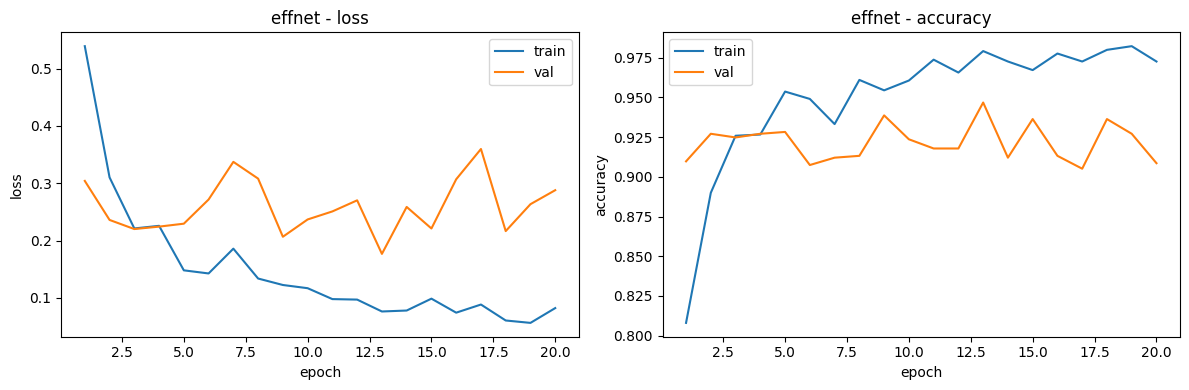


=== effnet / train ===
loss=0.0158  acc=0.9958  macro_f1=0.9957
              precision    recall  f1-score   support

       daisy     1.0000    0.9891    0.9945       458
   dandelion     0.9953    0.9984    0.9968       631
        rose     0.9957    0.9957    0.9957       470
   sunflower     0.9932    1.0000    0.9966       440
       tulip     0.9949    0.9949    0.9949       590

    accuracy                         0.9958      2589
   macro avg     0.9958    0.9956    0.9957      2589
weighted avg     0.9958    0.9958    0.9957      2589

confusion matrix (rows=true, cols=pred):
[[453   2   1   1   1]
 [  0 630   0   1   0]
 [  0   0 468   0   2]
 [  0   0   0 440   0]
 [  0   1   1   1 587]]

=== effnet / val ===
loss=0.1769  acc=0.9468  macro_f1=0.9465
              precision    recall  f1-score   support

       daisy     0.9545    0.9608    0.9577       153
   dandelion     0.9541    0.9905    0.9720       210
        rose     0.9236    0.9236    0.9236       157
   sunflo

In [ ]:
model_effnet.load_state_dict(torch.load("runs/effnet/best.pt", map_location=device))
plot_history(effnet_history, "effnet")

# full_eval uses the ResNet dataloaders; inline the loop with EffNet's instead.
for split_name, dl in [("train", train_effnet_dl),
                       ("val",   val_effnet_dl),
                       ("test",  test_effnet_dl)]:
    m = evaluate(model_effnet, dl, labels)
    print(f"\n=== effnet / {split_name} ===")
    print(f"loss={m['loss']:.4f}  acc={m['accuracy']:.4f}  "
          f"macro_f1={m['macro_f1']:.4f}")
    print(m["report"])
    print("confusion matrix (rows=true, cols=pred):")
    print(m["cm"])